In [1]:
# Draft of flowering time tutorial
# Keely Brown 07/30/2026

#Imports
%matplotlib widget
import plantcv.plantcv as pcv
import plantcv.geospatial as gcv


pcv.params.debug = "plot"

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.011026782..1.2745649].


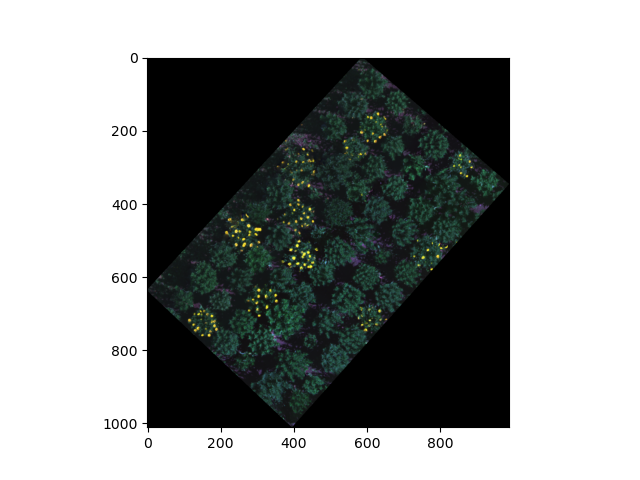

In [15]:
# Read in image
input_geotif = "./Flowering_tutorial_cropped.tif"
img = gcv.read.geotif(input_geotif, bands="b,g,r,re,nir")



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-40.816406..347.11368].


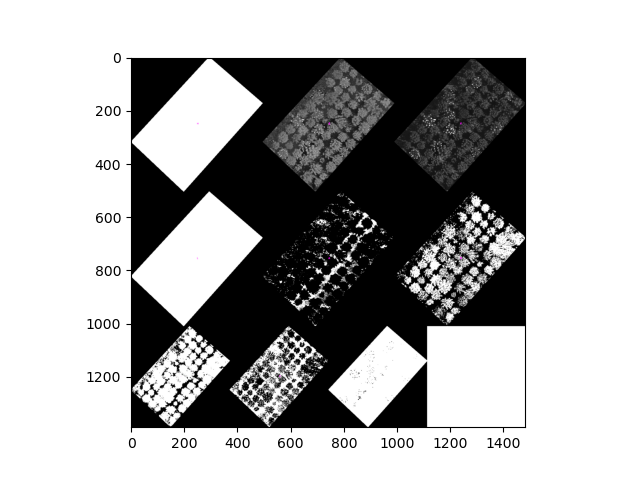

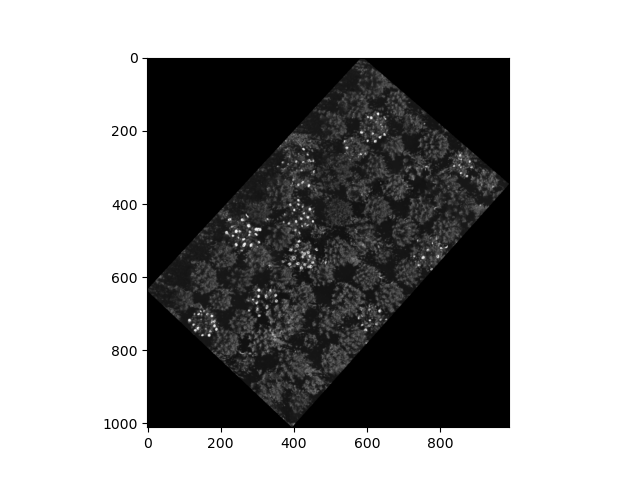

alt.Chart(...)

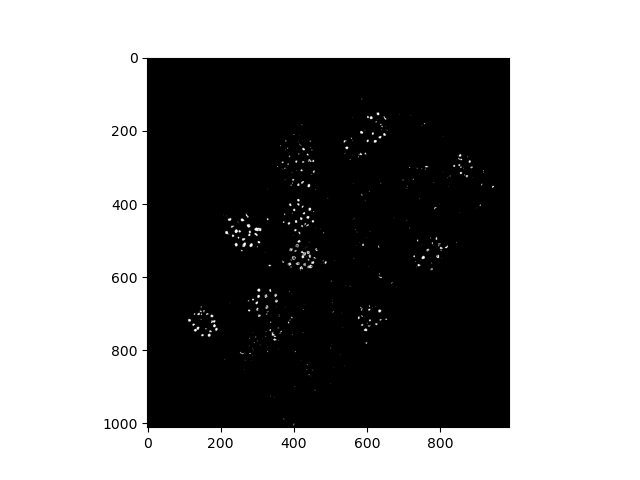

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.011026782..1.238254].


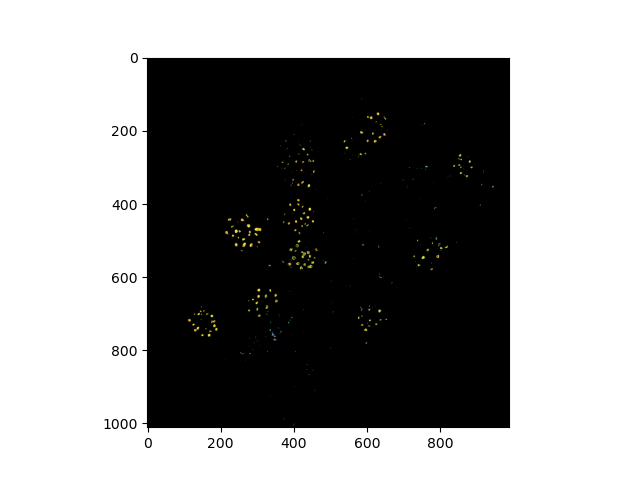

In [10]:
# Use main PlantCV to create a flower mask
pcv.visualize.colorspaces(img.thumb, original_img=False)

gray_v = pcv.rgb2gray_hsv(rescaled, channel="v")

pcv.visualize.histogram(gray_v)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.011026782..1.238254].


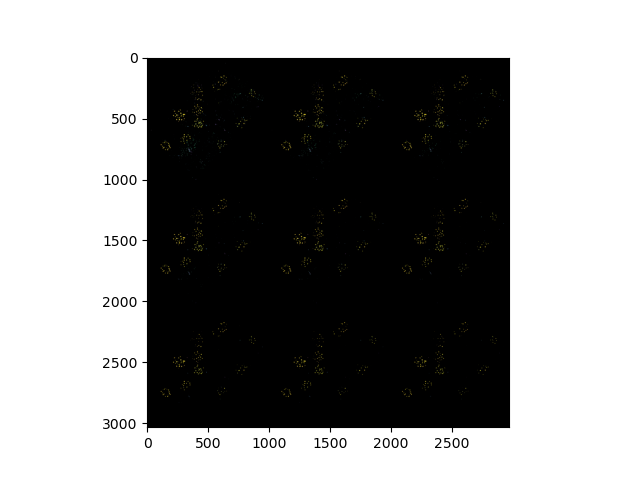

In [16]:
# Cycle through some values for the thresholding and look at them
# Looking for where most of the kept pixels look like flower color
threshvals = [110, 120, 130, 140, 150, 160, 170, 180, 190]
pcv.params.debug = None

masked_list = []
for i in threshvals:
    mask = pcv.threshold.binary(gray_v, threshold=i)
    masked = pcv.apply_mask(img.thumb, mask, mask_color="black")
    masked_list.append(masked)

pcv.params.debug = "plot"

tiled = pcv.visualize.tile(masked_list, ncol=3)

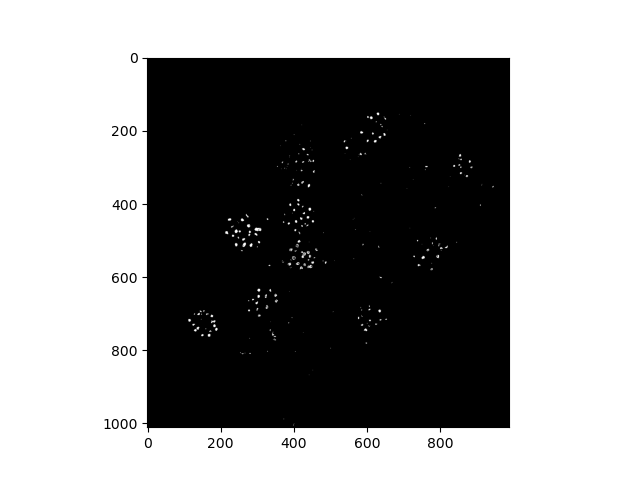

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.011026782..1.238254].


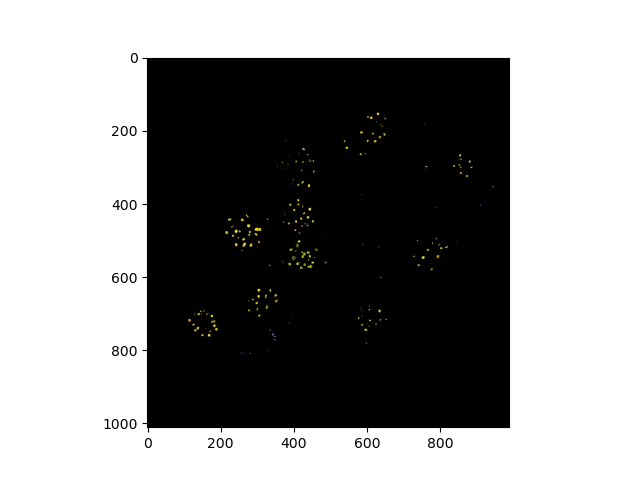

In [17]:
# Going with 150

mask = pcv.threshold.binary(gray_v, threshold=150)

masked = pcv.apply_mask(img.thumb, mask, mask_color="black")

In [18]:
# Create plant boundaries using the autogrid method on an InteractiveShapes object
# When the napari window opens, draw a rectangle around the field, as tightly as possible, in the 'field_boundary' layer

editor = gcv.create_shapes.InteractiveShapes(img, field_layer="field_boundary")



In [20]:
# After drawing a polygon around the field in the "field_boundary" layer, automatically draw a grid of lines
# You can edit the lines if they are off
editor.grid(numdivs=[6,11])


In [21]:
# After correcting lines until they enclose individual plots, 
# draw polygons using the line intersections
# You can edit the polygon vertices if they are still not perfect
editor.plots()


In [23]:
# Save plot boundaries to a file
plots = editor.to_shapes(dest="./plots.geojson", layername="Plots")

/Users/kbrown/miniforge3/envs/plantcv/lib/python3.12/site-packages/rasterstats/io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.011026782..1.2745649].


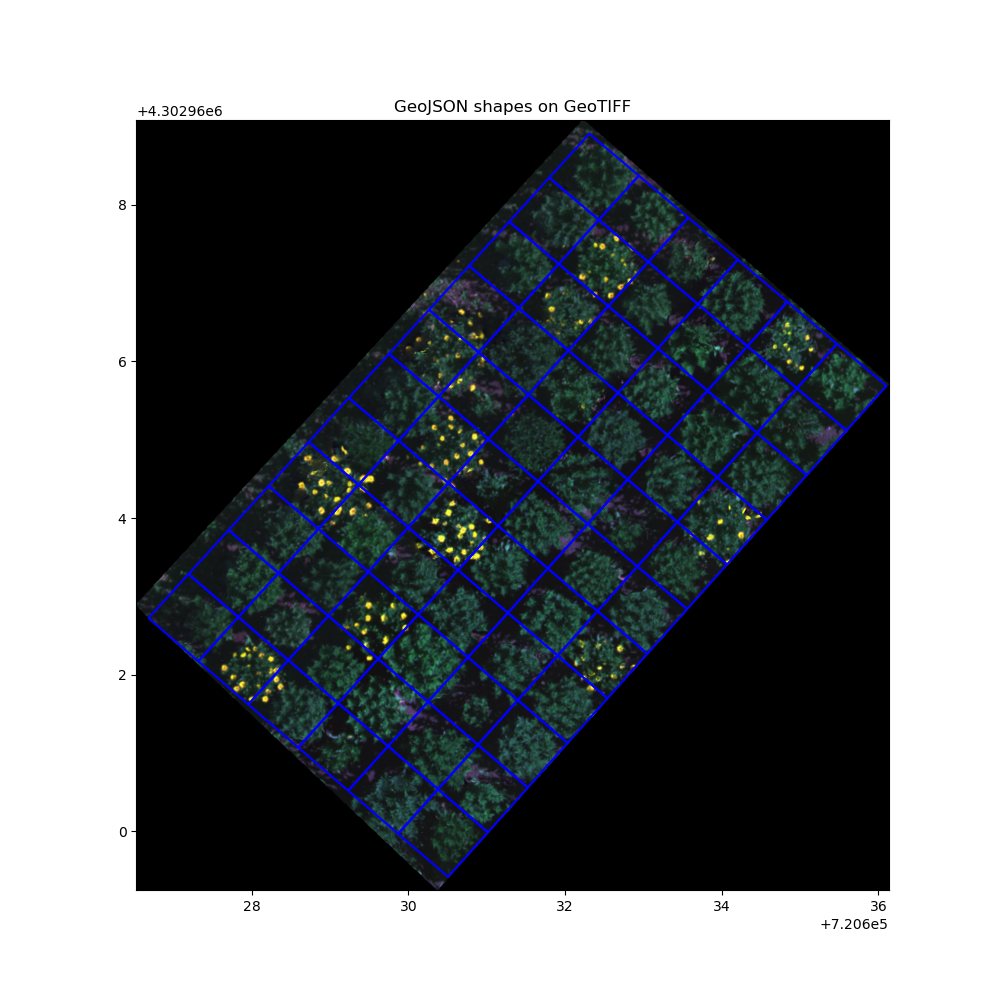

In [24]:
# Use the mask and plot boundaries to estimate coverage per plot
# If flowers are the same size, number of flower pixels could correlate with flower number

cov = gcv.analyze.coverage(img, mask, geojson="./plots.geojson")

In [ ]:
# Save results
pcv.outputs.save_results(filename="./coverage_results.csv", outformat="csv")